# YOLO + SAM: Detectando y Segmentando el Mundo 🌍

Bienvenidos a la demostración interactiva de visión computacional. En esta sesión no solo veremos cómo usar modelos estelares como **YOLO** (You Only Look Once) o **SAM** (Segment Anything Model), sino que entenderemos *por qué* necesitan trabajar juntos.

### 🖥️ Preparando el escenario 

In [1]:
import random
import numpy as np

import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO, SAM
from ultralytics.engine.results import Boxes

In [2]:
# YOLO11 es tan versátil que correrá en CPU, pero si tienes una GPU (NVIDIA CUDA) o Mac M1/M2 (MPS), la usaremos.
device = "cuda" if torch.cuda.is_available() else \
         "mps" if torch.backends.mps.is_available() else "cpu"

print(f"Dispositivo seleccionado para inferencia:\n{device}")

Dispositivo seleccionado para inferencia:
cuda


## 🎭 Acto 1: SAM y el Asombro del Detalle
Empecemos con **FastSAM**, una versión ultra-rápida de Segment Anything Model. 
SAM es capaz de recortar **cualquier** objeto en una imagen con precisión de píxel a píxel. Es ciego en cuanto a significado (no sabe qué es un 'perro' o una 'persona'), pero mecánicamente es un genio del recorte.

In [3]:
# Cargamos SAM Mobile (versión pequeña pero poderosa)
sam_model = SAM("local/weights/mobile_sam.pt")

In [4]:
# Le pedimos al modelo que fragmente ABSOLUTAMENTE TODO en la imagen",
results_sam = sam_model(
    # source: La ruta de la imagen, video, directorio o tensor que quieres procesar.
    source="local/assets/sample_images/la_oficina.jpg",
    
    # device: El hardware donde se ejecutará la inferencia ('cpu', 'cuda', 'mps' para Mac, o el índice de la GPU ej. 0).
    device=device,
    
    # retina_masks: Si es True, genera máscaras de alta resolución (igual a la imagen original). 
    # Si es False, usa máscaras de menor resolución para ganar velocidad, lo que puede hacer que los bordes se vean pixelados.
    retina_masks=True,
    
    # conf: El umbral de confianza (Confidence Threshold). Va de 0.0 a 1.0. 
    # Solo las detecciones/máscaras con una certeza igual o mayor al 90% (0.9) serán conservadas.
    conf=0.9
)


image 1/1 c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\parcial_3\yolo\local\assets\sample_images\la_oficina.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 1 58, 1 59, 1 60, 1 61, 1 62, 1 63, 1 64, 1 65, 1 66, 1 67, 1 68, 1 69, 1 70, 1 71, 1 72, 1 73, 1 74, 1 75, 1 76, 1 77, 1 78, 1 79, 1 80, 4654.0ms
Speed: 62.7ms preprocess, 4654.0ms inference, 5.1ms postprocess per image at shape (1, 3, 1024, 1024)


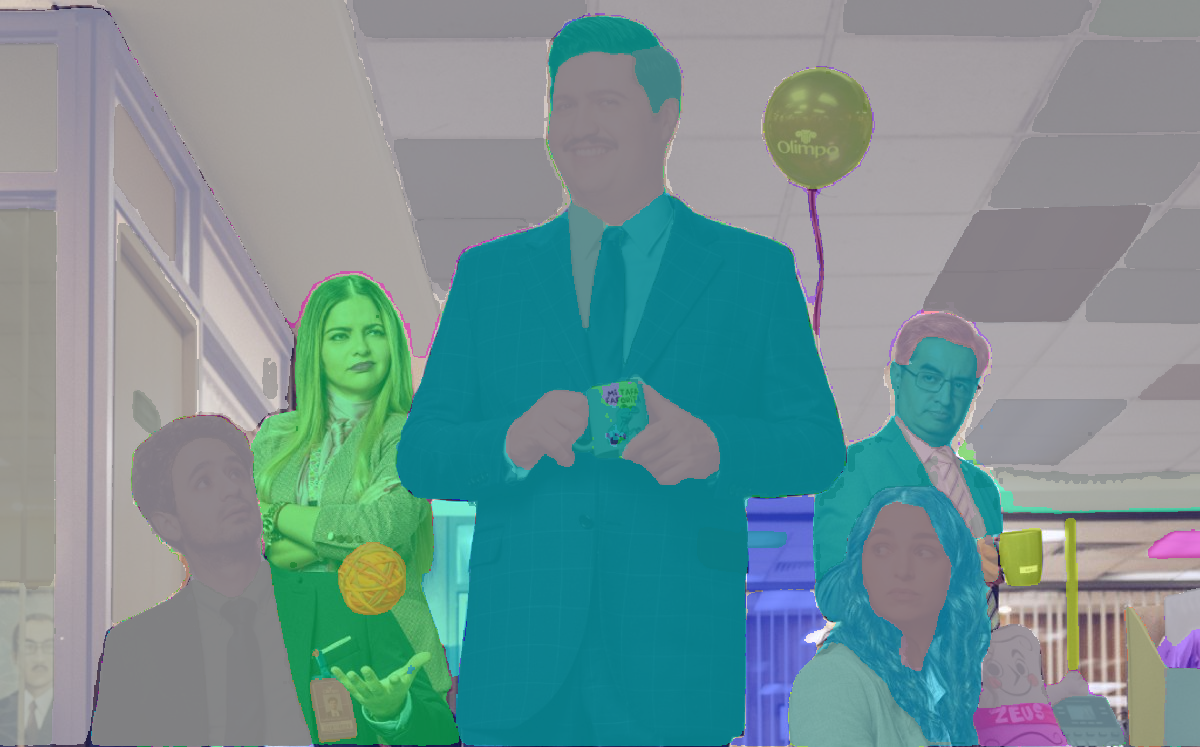

In [5]:
# 1. Extraemos la imagen con plot
# 2. Invertimos los canales de BGR a RGB usando slicing de NumPy: [..., ::-1]
# 3. Lo convertimos a un objeto de PIL que Jupyter mostrará automáticamente
Image.fromarray(results_sam[0].plot(boxes=False)[..., ::-1])

A class for storing and manipulating inference results.

    This class provides comprehensive functionality for handling inference results from various Ultralytics models,
    including detection, segmentation, classification, and pose estimation. It supports visualization, data export, and
    various coordinate transformations.

    Attributes:
        orig_img (np.ndarray): The original image as a numpy array.
        orig_shape (tuple[int, int]): Original image shape in (height, width) format.
        boxes (Boxes | None): Detected bounding boxes.
        masks (Masks | None): Segmentation masks.
        probs (Probs | None): Classification probabilities.
        keypoints (Keypoints | None): Detected keypoints.
        obb (OBB | None): Oriented bounding boxes.
        speed (dict): Dictionary containing inference speed information.
        names (dict): Dictionary mapping class indices to class names.
        path (str): Path to the input image file.
        save_dir (str | None): Directory to save results.

    Methods:
        update: Update the Results object with new detection data.
        cpu: Return a copy of the Results object with all tensors moved to CPU memory.
        numpy: Convert all tensors in the Results object to numpy arrays.
        cuda: Move all tensors in the Results object to GPU memory.
        to: Move all tensors to the specified device and dtype.
        new: Create a new Results object with the same image, path, names, and speed attributes.
        plot: Plot detection results on an input BGR image.
        show: Display the image with annotated inference results.
        save: Save annotated inference results image to file.
        verbose: Return a log string for each task in the results.
        save_txt: Save detection results to a text file.
        save_crop: Save cropped detection images to specified directory.
        summary: Convert inference results to a summarized dictionary.
        to_df: Convert detection results to a Polars DataFrame.
        to_json: Convert detection results to JSON format.
        to_csv: Convert detection results to a CSV format.

In [6]:
# 1. Extraemos el tensor con la data de todas las cajas
boxes_data = results_sam[0].boxes.data

boxes_data[0]

tensor([397.2656, 200.3906, 843.7500, 744.1406,   1.0283,   0.0000], device='cuda:0')

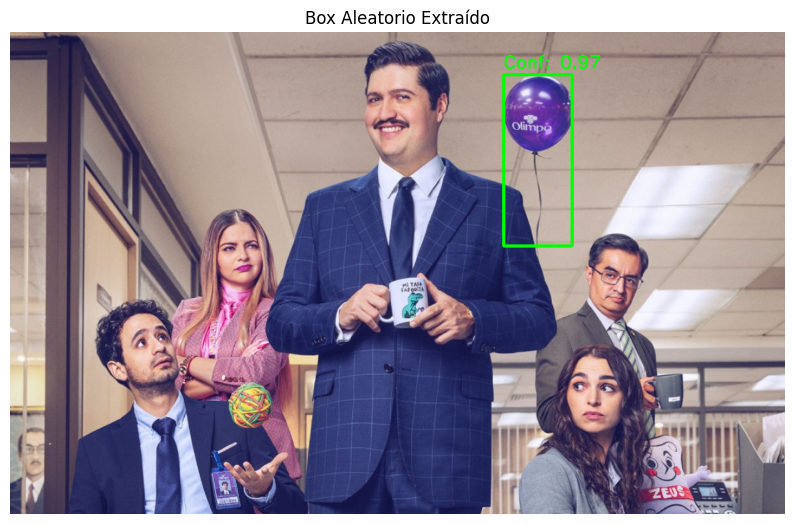

In [17]:
# 2. Verificamos que el modelo haya encontrado al menos una caja
if len(boxes_data) > 0:
    
    # Elegimos un índice al azar
    idx_aleatorio = random.randint(0, len(boxes_data) - 1)
    
    # Extraemos la caja aleatoria.
    # El formato por defecto es [x1, y1, x2, y2, conf, clase]
    caja_elegida = boxes_data[idx_aleatorio]
    
    # Tomamos solo las coordenadas (los primeros 4 valores) y las pasamos a enteros
    x1, y1, x2, y2 = map(int, caja_elegida[:4])
    
    # 3. Hacemos una copia de la imagen original para no alterar el objeto de Ultralytics
    # orig_img está en formato BGR (el estándar de OpenCV)
    imagen_original = results_sam[0].orig_img.copy()
    
    # 4. Dibujamos el rectángulo en la imagen
    # Parámetros: imagen, (x1, y1), (x2, y2), color en BGR (ej. verde), grosor de línea
    cv2.rectangle(imagen_original, (x1, y1), (x2, y2), (0, 255, 0), 3)
    
    # Opcional: Agregar texto con la confianza del box
    confianza = float(caja_elegida[4])
    cv2.putText(imagen_original, f"Conf: {confianza:.2f}", (x1, y1 - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    
    # 5. Mostramos la imagen con Matplotlib (convirtiendo de BGR a RGB para que los colores se vean bien)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Box Aleatorio Extraído")
    plt.show()

else:
    print("El modelo no encontró ningún box con el umbral de confianza establecido.")

## 🎭 Acto 2: YOLO y el Poder del Contexto
A diferencia de SAM, **YOLO** sabe perfectamente qué está viendo (si la clase está dentro de sus 80 categorías conocidas). Sacrifica los bordes curvados perfectos a cambio de **velocidad extrema** y cajas delimitadoras que te dicen: *"Ahí hay un auto, acá una persona"*.


image 1/1 c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\parcial_3\yolo\local\assets\sample_images\la_oficina.jpg: 416x640 7 persons, 2 ties, 81.3ms
Speed: 2.4ms preprocess, 81.3ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 640)

🔎 YOLO detectó 9 objetos reconocidos.
Nivel de confianza de la primera detección: 0.94


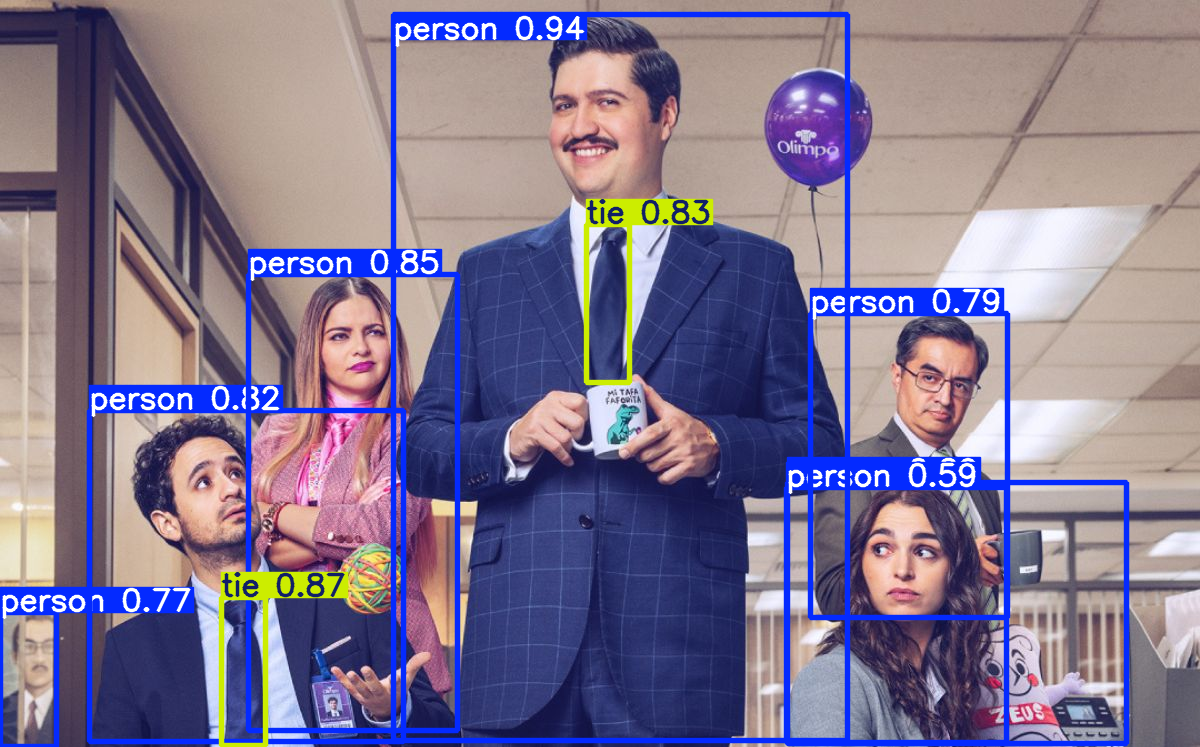

In [8]:
# Cargamos el modelo nano de YOLO11 (6 MB)
yolo_model = YOLO("local/weights/yolo11n.pt")

# Hacemos inferencia sobre una imagen urbana
results_yolo = yolo_model("local/assets/sample_images/la_oficina.jpg", device=device)

# Podemos inspeccionar el contenido que detectó:
print(f"\n🔎 YOLO detectó {len(results_yolo[0].boxes)} objetos reconocidos.")
print(f"Nivel de confianza de la primera detección: {results_yolo[0].boxes.conf[0]:.2f}")

Image.fromarray(results_yolo[0].plot(boxes=True)[..., ::-1])

## 🎭 Acto 3: El Matrimonio Perfecto (Pipeline YOLO 🤝 SAM)
¿Qué pasa si queremos lo mejor de ambos mundos? 
- Queremos saber **QUÉ** son los objetos y filtrarlos velozmente (YOLO).
- Queremos **RECORTARLOS** con máscaras perfectas para producción gráfica (SAM).

> **Estrategia (Detector-then-Segmenter)**: Usamos las cajas que escupe YOLO como las *pistas (prompts)* para decirle a SAM exactamente *dónde* tiene que hacer sus máscaras perfectas.

In [9]:
imagen_path = "local/assets/sample_images/la_oficina.jpg"

# 1. YOLO detecta y clasifica
resultados_yolo = yolo_model(imagen_path)[0]
cajas_yolo = resultados_yolo.boxes.xyxy 

# 2. SAM segmenta usando las cajas de YOLO
resultados_yolo_sam = sam_model(
    source=imagen_path,
    bboxes=cajas_yolo,
    device=device 
)[0]


image 1/1 c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\parcial_3\yolo\local\assets\sample_images\la_oficina.jpg: 416x640 7 persons, 2 ties, 22.9ms
Speed: 1.9ms preprocess, 22.9ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\parcial_3\yolo\local\assets\sample_images\la_oficina.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 52.4ms
Speed: 11.1ms preprocess, 52.4ms inference, 1.9ms postprocess per image at shape (1, 3, 1024, 1024)


In [10]:
for _ in range(5):
    random_key = random.choice(list(resultados_yolo.names.keys()))
    print(f"Key {random_key}: {resultados_yolo.names[random_key]}")

Key 78: hair drier
Key 50: broccoli
Key 5: bus
Key 69: oven
Key 33: kite


In [11]:
# 1. Copiamos el diccionario de nombres
resultados_yolo_sam.names = resultados_yolo.names 

# 2. Hacemos un CLON del tensor para salir del modo de solo lectura
nuevo_tensor = resultados_yolo_sam.boxes.data.clone()

En Ultralytics, cuando accedes al atributo principal `.data` de las cajas, te devuelve un tensor bidimensional (una matriz) donde cada fila es un objeto detectado y cada columna tiene un dato específico.

Por convención, Ultralytics **siempre** organiza las columnas en este orden exacto (formato `xyxy`):

| Índice de Columna | 0 | 1 | 2 | 3 | 4 | **5** |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Significado** | **x1** (Cordenada X inicial) | **y1** (Coordenada Y inicial) | **x2** (Coordenada X final) | **y2** (Coordenada Y final) | **conf** (Nivel de confianza) | **cls** (ID de la Clase) |
| *Ejemplo (Caja 1)* | 120.5 | 45.2 | 300.8 | 400.1 | 0.95 | **0** (Persona) |
| *Ejemplo (Caja 2)* | 50.0 | 80.0 | 100.0 | 150.0 | 0.88 | **63** (Laptop) |

La notación `[:, 5]` es sintaxis pura de tensores (heredada de NumPy). Significa:
* **`:` (Dos puntos):** Selecciona *todas las filas* (es decir, todas las cajas que se detectaron).
* **`5`:** Selecciona únicamente la *columna en la posición 5* (que, como empezamos a contar desde 0, es la sexta columna: la de la **clase**).

Entonces, `nuevo_tensor[:, 5]` aísla toda la columna de los IDs de clase del modelo SAM.


Para facilitarte la vida, los desarrolladores de Ultralytics crearon "atajos" (propiedades) para que no tengas que memorizar el orden de esas columnas. 

El atributo `.boxes.cls` es simplemente un atajo seguro y rápido que extrae esa misma columna `5` del tensor, pero del modelo YOLO. En lugar de devolverte toda la matriz con coordenadas, te devuelve un tensor de una sola dimensión (una lista) solo con los números de las clases detectadas.

Por ejemplo, si YOLO detectó dos personas y una laptop, `resultados_yolo.boxes.cls` te devolvería algo como: `tensor([0., 0., 63.])`.

Lo que estamos diciendo aquí en español es: 
*"Ve a la matriz clonada de SAM, toma la columna donde se guardan las clases (`[:, 5]`), bórrala, y pégale encima la lista exacta de clases que ya procesó y clasificó YOLO (`boxes.cls`)."* Así, SAM se queda con sus propias coordenadas (columnas 0 a 3) y su propia confianza (columna 4), pero adopta el "cerebro" clasificador de YOLO en la columna 5.

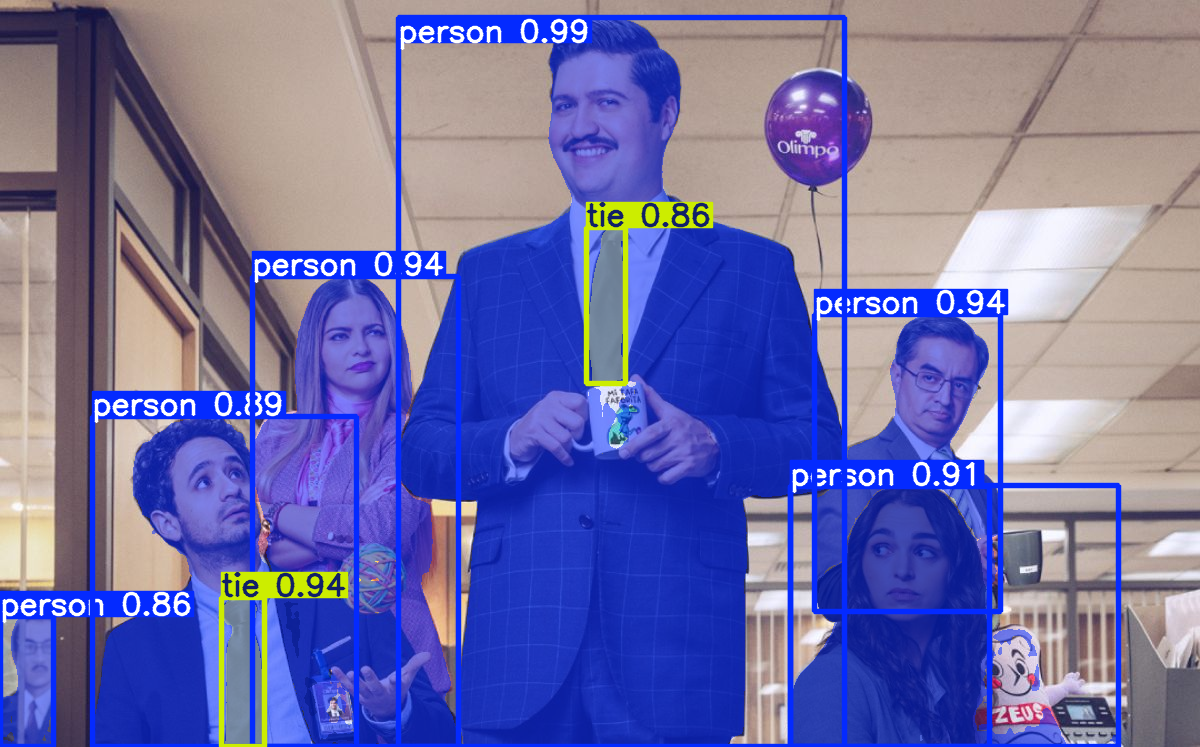

In [12]:
# 3. Modificamos el clon
nuevo_tensor[:, 5] = resultados_yolo.boxes.cls 

# 4. Reemplazamos el objeto Boxes de SAM por uno nuevo usando nuestro tensor modificado
resultados_yolo_sam.boxes = Boxes(nuevo_tensor, resultados_yolo_sam.boxes.orig_shape)

# 5. Al usar .plot(), SAM leerá las clases de YOLO perfectamente y se mostrará en el Notebook
Image.fromarray(resultados_yolo_sam.plot(boxes=True)[..., ::-1])

In [13]:
resultados_yolo_sam.masks.data[0]

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')

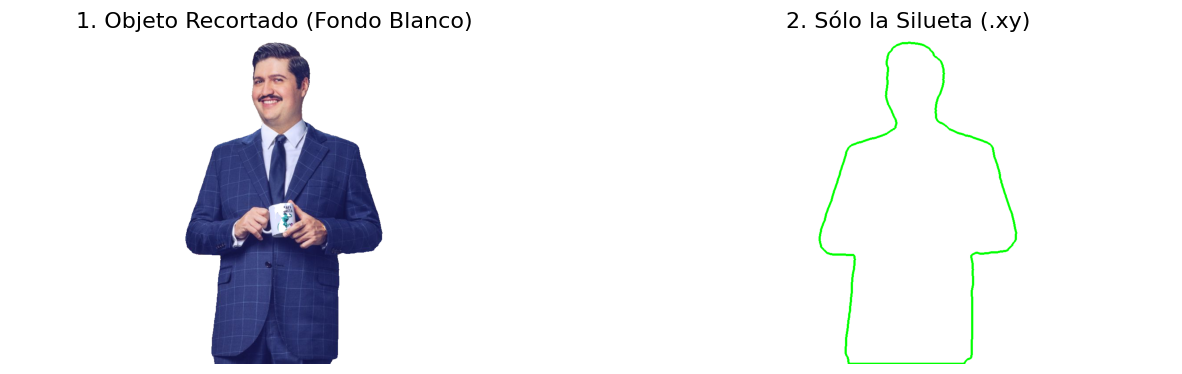

In [14]:
# Tomamos la imagen original y la información de la primera máscara detectada
img = resultados_yolo_sam.orig_img
mascara_matriz = resultados_yolo_sam.masks.data[0].cpu().numpy().astype(np.uint8)
coordenadas_xy = resultados_yolo_sam.masks.xy[0].astype(np.int32) # Pasamos a enteros para OpenCV

# --- 1. EXTRAER EL OBJETO RECORTADO (CON FONDO BLANCO) ---
mascara_redimensionada = cv2.resize(mascara_matriz, (img.shape[1], img.shape[0]))
mascara_3d = np.expand_dims(mascara_redimensionada, axis=-1)

# CAMBIO: Usamos np.where. Si la máscara tiene 1, deja el píxel de 'img'. Si es 0, pon 255 (blanco).
objeto_recortado = np.where(mascara_3d == 1, img, 255).astype(np.uint8)

# --- 2. EXTRAER SÓLO LA SILUETA (.xy) ---
# Creamos un "lienzo" blanco del mismo tamaño que la imagen original.
# (Nota: Si prefieres que el fondo sea negro para que el verde resalte más, 
# cambia np.ones_like(...) * 255 por np.zeros_like(...))
lienzo_blanco = np.ones_like(img, dtype=np.uint8) * 255

# Dibujamos el polígono sobre nuestro lienzo nuevo en lugar de la imagen original
silueta = cv2.polylines(lienzo_blanco, [coordenadas_xy], isClosed=True, color=(0, 255, 0), thickness=4)

# --- VISUALIZACIÓN ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.imshow(cv2.cvtColor(objeto_recortado, cv2.COLOR_BGR2RGB))
ax1.set_title("1. Objeto Recortado (Fondo Blanco)", fontsize=16)
ax1.axis('off')

ax2.imshow(cv2.cvtColor(silueta, cv2.COLOR_BGR2RGB))
ax2.set_title("2. Sólo la Silueta (.xy)", fontsize=16)
ax2.axis('off')

plt.show()